# 07, Final Comparison: Pipeline vs LLM Across Tasks (Updated)

Synthesises results from notebooks 03–09 into a single cross-task comparison.
This notebook contains no API calls and no heavy computation.

**Systems compared:**

| System | Type | Size | Input | Task |
|--------|------|------|-------|------|
| spaCy de_core_news_lg | Pipeline |, | German | NER |
| Stanza German | Pipeline |, | German | NER |
| Flair German | Pipeline |, | German | NER |
| BERTopic multilingual | Pipeline |, | German | Topics |
| Qwen2.5-7B-Instruct | LLM | 7B | English (OPUS-MT) | NER |
| Llama 3.3 70B | LLM | 70B | English (OPUS-MT) | NER + Topics |

**Research question**: Can task-specific NLP pipelines match LLM performance
on cross-lingual text analysis while offering advantages in transparency,
reproducibility, and resource efficiency?


In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy
print('Done')

Done


In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('Imports OK')

Imports OK


In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import yaml

PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Config loaded | seed={SEED}')

Mounted at /content/drive
Config loaded | seed=42


In [5]:
# Load all summaries
with open(DATA_PROC / 'ner_comparison_summary.json') as f:
    ner_summary = json.load(f)

with open(DATA_PROC / 'topic_modeling_summary.json') as f:
    topic_summary = json.load(f)

with open(DATA_PROC / 'nb09_llama70b_summary.json') as f:
    llama_summary = json.load(f)

# Extract key numbers
ner_f1   = ner_summary['macro_f1']
ner_ci   = ner_summary['bootstrap_ci_95']
ner_prec = ner_summary['macro_precision']
ner_rec  = ner_summary['macro_recall']

spacy_f1  = ner_f1['spaCy (DE)']
stanza_f1 = ner_f1['Stanza (DE)']
flair_f1  = ner_f1['Flair (DE)']
qwen_f1   = ner_f1['Qwen (EN)']
llama_f1  = llama_summary['ner_macro_f1']
llama_ci  = {'lower': llama_summary['ner_f1_ci_lower'],
             'upper': llama_summary['ner_f1_ci_upper']}

print('NER F1 summary:')
print(f'  spaCy (DE)         : {spacy_f1:.3f}')
print(f'  Stanza (DE)        : {stanza_f1:.3f}')
print(f'  Flair (DE)         : {flair_f1:.3f}')
print(f'  Qwen 7B (EN)       : {qwen_f1:.3f}')
print(f'  Llama 3.3 70B (EN) : {llama_f1:.3f}')
print(f'\nTopic modeling:')
print(f'  BERTopic C_v       : {topic_summary["cv_coherence"]:.4f}')
print(f'  Llama 70B kappa    : {llama_summary["topic_cohens_kappa"]:.3f}')
print(f'  Llama 70B match    : {llama_summary["topic_exact_match"]:.3f}')

NER F1 summary:
  spaCy (DE)         : 0.394
  Stanza (DE)        : 0.520
  Flair (DE)         : 0.717
  Qwen 7B (EN)       : 0.191
  Llama 3.3 70B (EN) : 0.340

Topic modeling:
  BERTopic C_v       : 0.3971
  Llama 70B kappa    : 0.403
  Llama 70B match    : 0.500


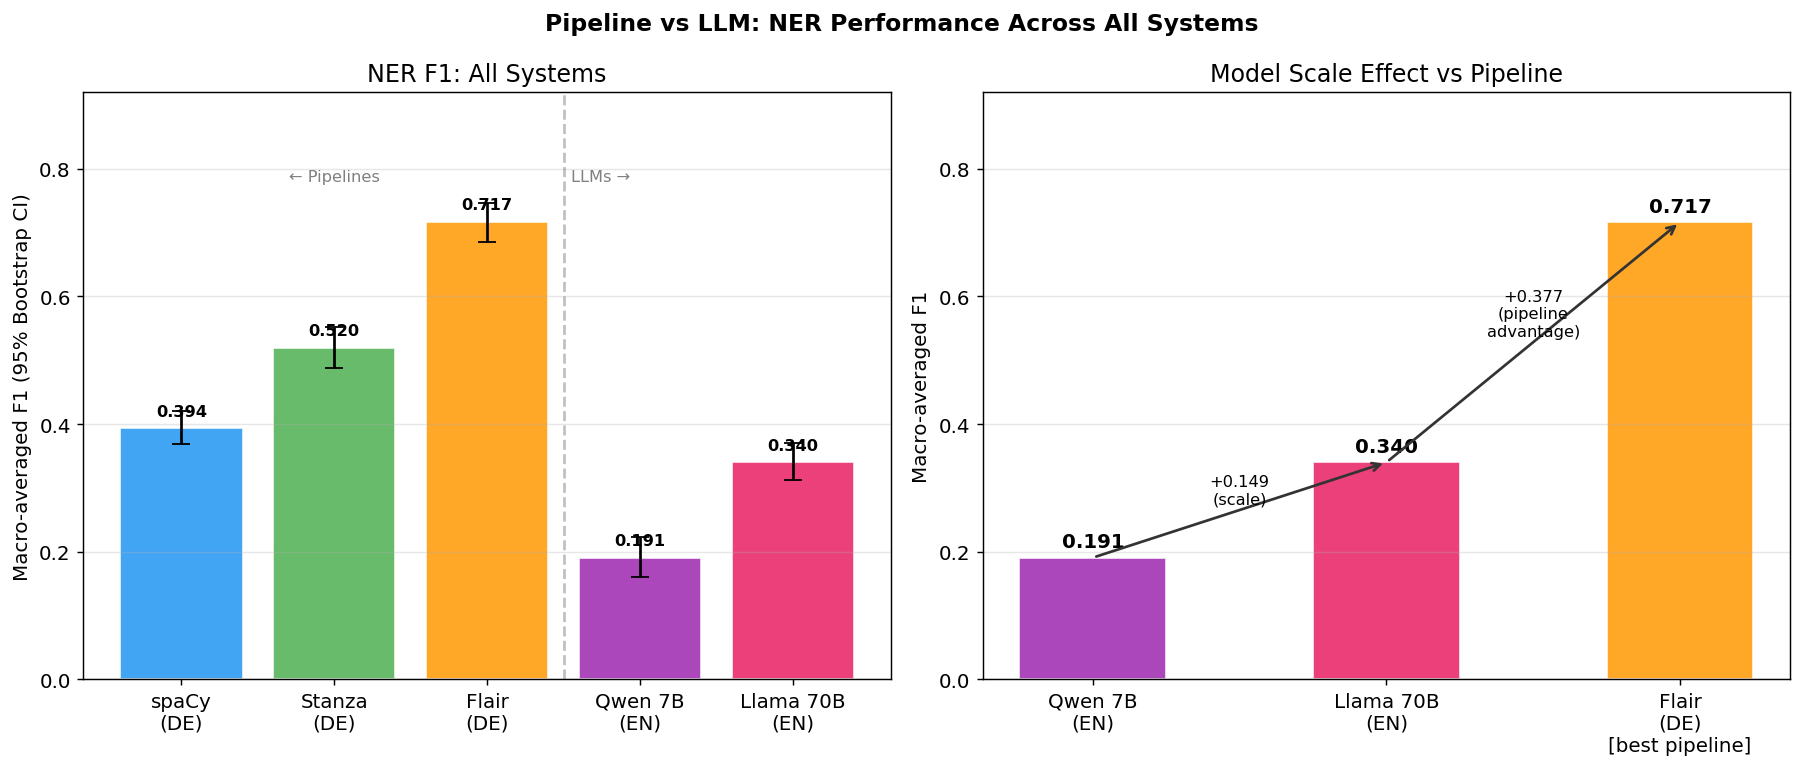

Figure 1 saved


In [6]:
# Figure 1: Full NER comparison — all 5 systems
systems_plot = [
    ('spaCy\n(DE)',      spacy_f1,  ner_ci['spaCy (DE)'],   '#2196F3', 'Pipeline'),
    ('Stanza\n(DE)',     stanza_f1, ner_ci['Stanza (DE)'],  '#4CAF50', 'Pipeline'),
    ('Flair\n(DE)',      flair_f1,  ner_ci['Flair (DE)'],   '#FF9800', 'Pipeline'),
    ('Qwen 7B\n(EN)',    qwen_f1,   ner_ci['Qwen (EN)'],    '#9C27B0', 'LLM 7B'),
    ('Llama 70B\n(EN)', llama_f1,  llama_ci,               '#E91E63', 'LLM 70B'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Pipeline vs LLM: NER Performance Across All Systems',
             fontsize=13, fontweight='bold')

# Left: full comparison bar chart
ax = axes[0]
names  = [s[0] for s in systems_plot]
f1s    = [s[1] for s in systems_plot]
colors = [s[3] for s in systems_plot]
cis    = [s[2] for s in systems_plot]

bars = ax.bar(names, f1s, color=colors, alpha=0.85, edgecolor='white')
for i, (bar, f1, ci) in enumerate(zip(bars, f1s, cis)):
    ax.errorbar(i, f1,
                yerr=[[f1 - ci['lower']], [ci['upper'] - f1]],
                fmt='none', color='black', capsize=5, linewidth=1.5)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{f1:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axvline(2.5, color='gray', linestyle='--', alpha=0.5)
ax.text(2.55, 0.78, 'LLMs →', fontsize=9, color='gray')
ax.text(1.0, 0.78, '← Pipelines', fontsize=9, color='gray', ha='center')
ax.set_ylabel('Macro-averaged F1 (95% Bootstrap CI)')
ax.set_title('NER F1: All Systems')
ax.set_ylim(0, 0.92)
ax.grid(axis='y', alpha=0.3)

# Right: model scale effect
ax2 = axes[1]
scale_names   = ['Qwen 7B\n(EN)', 'Llama 70B\n(EN)', 'Flair\n(DE)\n[best pipeline]']
scale_f1s     = [qwen_f1, llama_f1, flair_f1]
scale_colors  = ['#9C27B0', '#E91E63', '#FF9800']

bars2 = ax2.bar(scale_names, scale_f1s, color=scale_colors,
                alpha=0.85, edgecolor='white', width=0.5)
for bar, f1 in zip(bars2, scale_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{f1:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Annotate scale effect
ax2.annotate('', xy=(1, llama_f1), xytext=(0, qwen_f1),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
ax2.text(0.5, (qwen_f1 + llama_f1)/2 + 0.01,
         f'+{llama_f1 - qwen_f1:.3f}\n(scale)', ha='center', fontsize=9)

# Annotate remaining pipeline gap
ax2.annotate('', xy=(2, flair_f1), xytext=(1, llama_f1),
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))
ax2.text(1.5, (llama_f1 + flair_f1)/2 + 0.01,
         f'+{flair_f1 - llama_f1:.3f}\n(pipeline\nadvantage)', ha='center', fontsize=9)

ax2.set_ylabel('Macro-averaged F1')
ax2.set_title('Model Scale Effect vs Pipeline')
ax2.set_ylim(0, 0.92)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_ner_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

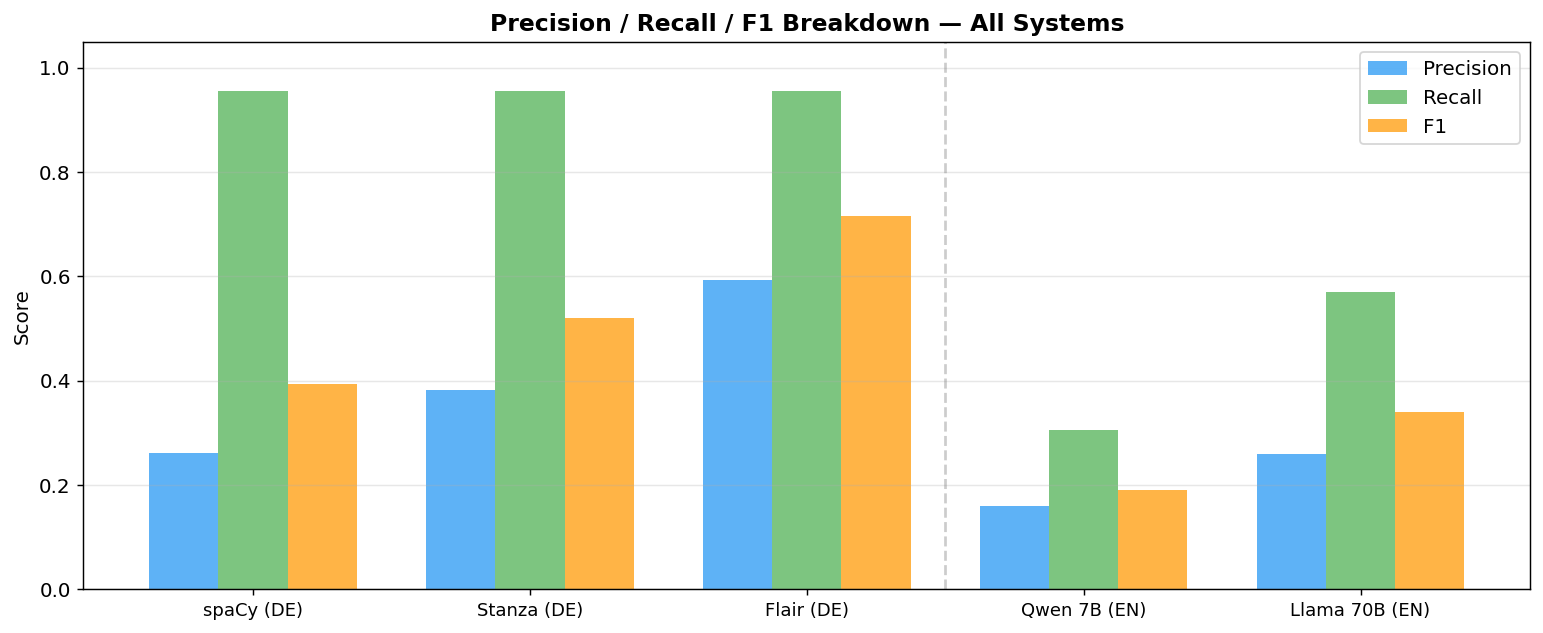

Figure 2 saved


In [7]:
# Figure 2: Precision / Recall breakdown — all systems
fig, ax = plt.subplots(figsize=(12, 5))

all_systems = ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen 7B (EN)', 'Llama 70B (EN)']
precisions  = [
    ner_prec['spaCy (DE)'], ner_prec['Stanza (DE)'], ner_prec['Flair (DE)'],
    ner_prec['Qwen (EN)'], llama_summary['ner_macro_precision']
]
recalls = [
    ner_rec['spaCy (DE)'], ner_rec['Stanza (DE)'], ner_rec['Flair (DE)'],
    ner_rec['Qwen (EN)'], llama_summary['ner_macro_recall']
]
f1_vals = [spacy_f1, stanza_f1, flair_f1, qwen_f1, llama_f1]

x     = np.arange(len(all_systems))
width = 0.25

ax.bar(x - width, precisions, width, label='Precision', color='#42A5F5', alpha=0.85)
ax.bar(x,         recalls,    width, label='Recall',    color='#66BB6A', alpha=0.85)
ax.bar(x + width, f1_vals,    width, label='F1',        color='#FFA726', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_systems, fontsize=10)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 Breakdown — All Systems',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.4)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_prf_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

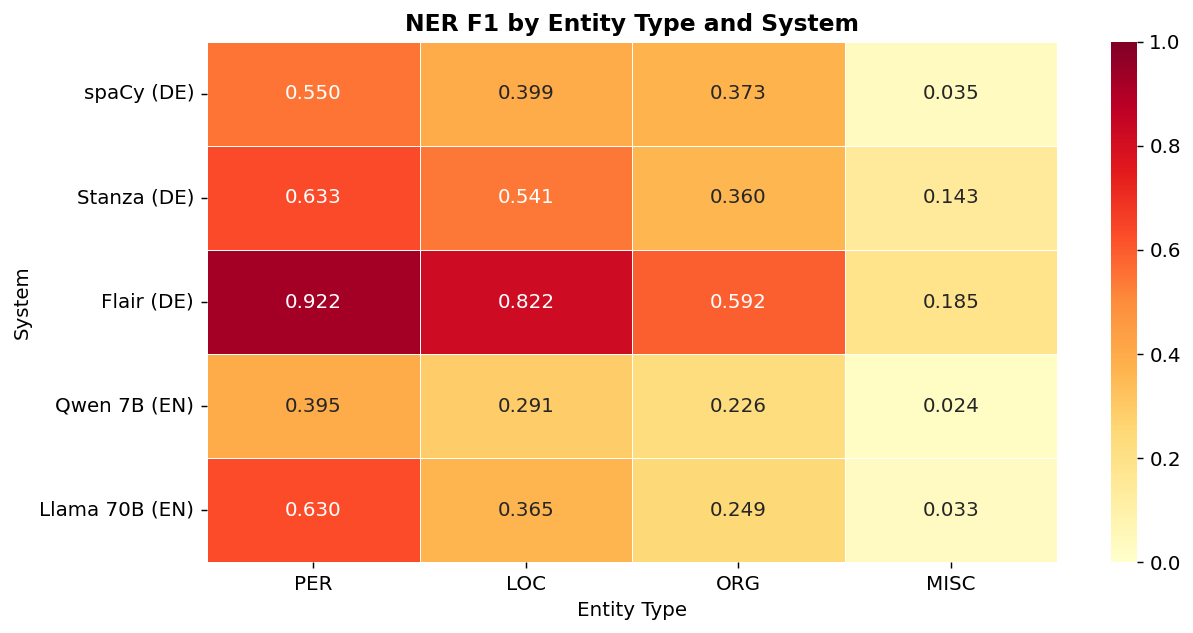

Figure 3 saved
                  PER    LOC    ORG   MISC
spaCy (DE)      0.550  0.399  0.373  0.035
Stanza (DE)     0.633  0.541  0.360  0.143
Flair (DE)      0.922  0.822  0.592  0.185
Qwen 7B (EN)    0.395  0.291  0.226  0.024
Llama 70B (EN)  0.630  0.365  0.250  0.032


In [8]:
# Figure 3: Per-label F1 heatmap — all systems including Llama 70B
label_f1_nb05  = ner_summary['per_label_f1']
label_f1_llama = {}

# Recompute per-label for Llama 70B from checkpoint
import pickle
with open(DATA_PROC / 'ner_llama70b_checkpoint.pkl', 'rb') as f:
    llama_ner = pickle.load(f)

agree_df = pd.read_csv(DATA_PROC / 'ner_agreement.csv')
gold_df  = agree_df[agree_df['agreement_level'] == 'full'].copy()
gold_df['entity_text_lower'] = gold_df['entity_text'].str.lower().str.strip()
gold_sets = (
    gold_df.groupby('article_id')
    .apply(lambda g: set(zip(g['entity_text_lower'], g['entity_label'])))
    .to_dict()
)

VALID_LABELS = {'PER', 'LOC', 'ORG', 'MISC'}

for label in ['PER', 'LOC', 'ORG', 'MISC']:
    tp = fp = fn = 0
    for aid, result in llama_ner.items():
        if result.get('status') != 'ok':
            continue
        gold = {e for e in gold_sets.get(aid, set()) if e[1] == label}
        pred = {
            (str(e.get('text', '')).lower().strip(), label)
            for e in result.get('entities', [])
            if isinstance(e, dict) and str(e.get('label', '')).upper() == label
        }
        tp += len(pred & gold)
        fp += len(pred - gold)
        fn += len(gold - pred)
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    label_f1_llama[label] = round(f1, 4)

# Build heatmap DataFrame
heatmap_data = pd.DataFrame({
    'spaCy (DE)'    : label_f1_nb05['spaCy (DE)'],
    'Stanza (DE)'   : label_f1_nb05['Stanza (DE)'],
    'Flair (DE)'    : label_f1_nb05['Flair (DE)'],
    'Qwen 7B (EN)'  : label_f1_nb05['Qwen (EN)'],
    'Llama 70B (EN)': label_f1_llama,
}).T

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.3f',
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('NER F1 by Entity Type and System',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Entity Type')
ax.set_ylabel('System')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_label_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')
print(heatmap_data.round(3).to_string())

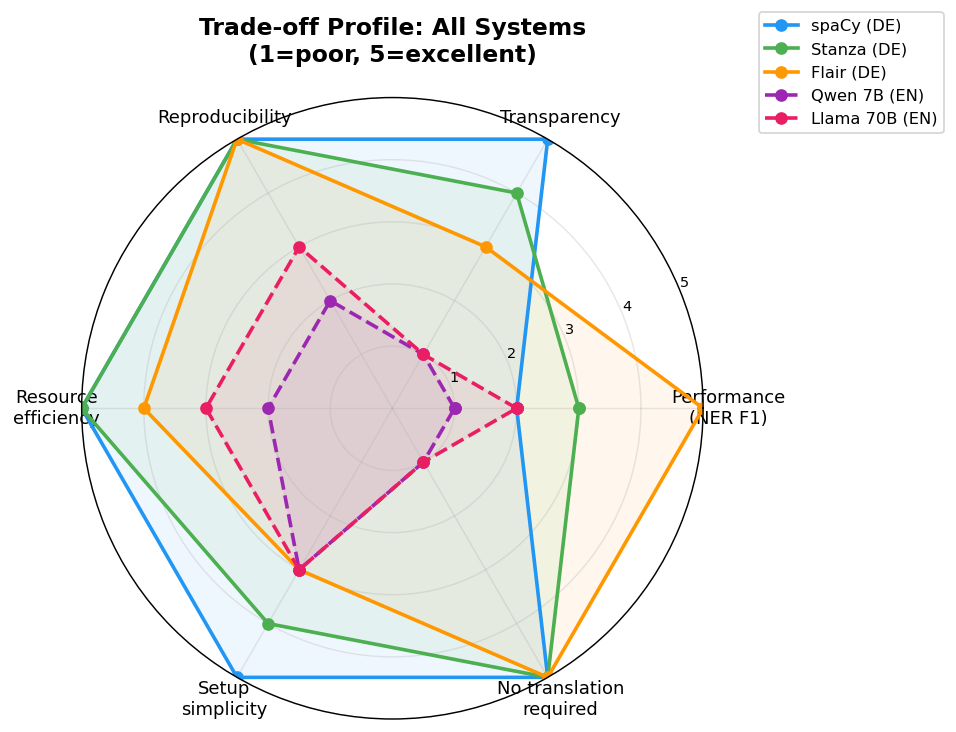

Figure 4 saved


In [9]:
# Figure 4: Trade-off radar — all 5 systems
dimensions = [
    'Performance\n(NER F1)',
    'Transparency',
    'Reproducibility',
    'Resource\nefficiency',
    'Setup\nsimplicity',
    'No translation\nrequired',
]

# Scores 1-5 (higher = better)
# Performance: scaled from F1 (spaCy=2, Stanza=3, Flair=5, Qwen=1, Llama=2)
# Transparency: pipeline systems expose model weights/keywords; LLMs are black-box
# Reproducibility: pipeline deterministic; LLM subject to API changes
# Resource efficiency: pipeline local/free; Qwen had credit issues; Llama Groq free tier
# Setup simplicity: spaCy/Stanza easy; Flair medium; LLMs need API management
# No translation: pipelines on German directly; LLMs need OPUS-MT translation first

systems_radar = {
    'spaCy (DE)'     : [2, 5, 5, 5, 5, 5],
    'Stanza (DE)'    : [3, 4, 5, 5, 4, 5],
    'Flair (DE)'     : [5, 3, 5, 4, 3, 5],
    'Qwen 7B (EN)'   : [1, 1, 2, 2, 3, 1],
    'Llama 70B (EN)' : [2, 1, 3, 3, 3, 1],
}

angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']
styles       = ['-', '-', '-', '--', '--']

for (sys_name, scores), color, style in zip(systems_radar.items(), colors_radar, styles):
    values = scores + scores[:1]
    ax.plot(angles, values, 'o' + style, linewidth=2,
            label=sys_name, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, size=10)
ax.set_ylim(0, 5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], size=8)
ax.set_title('Trade-off Profile: All Systems\n(1=poor, 5=excellent)',
             size=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_tradeoff_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

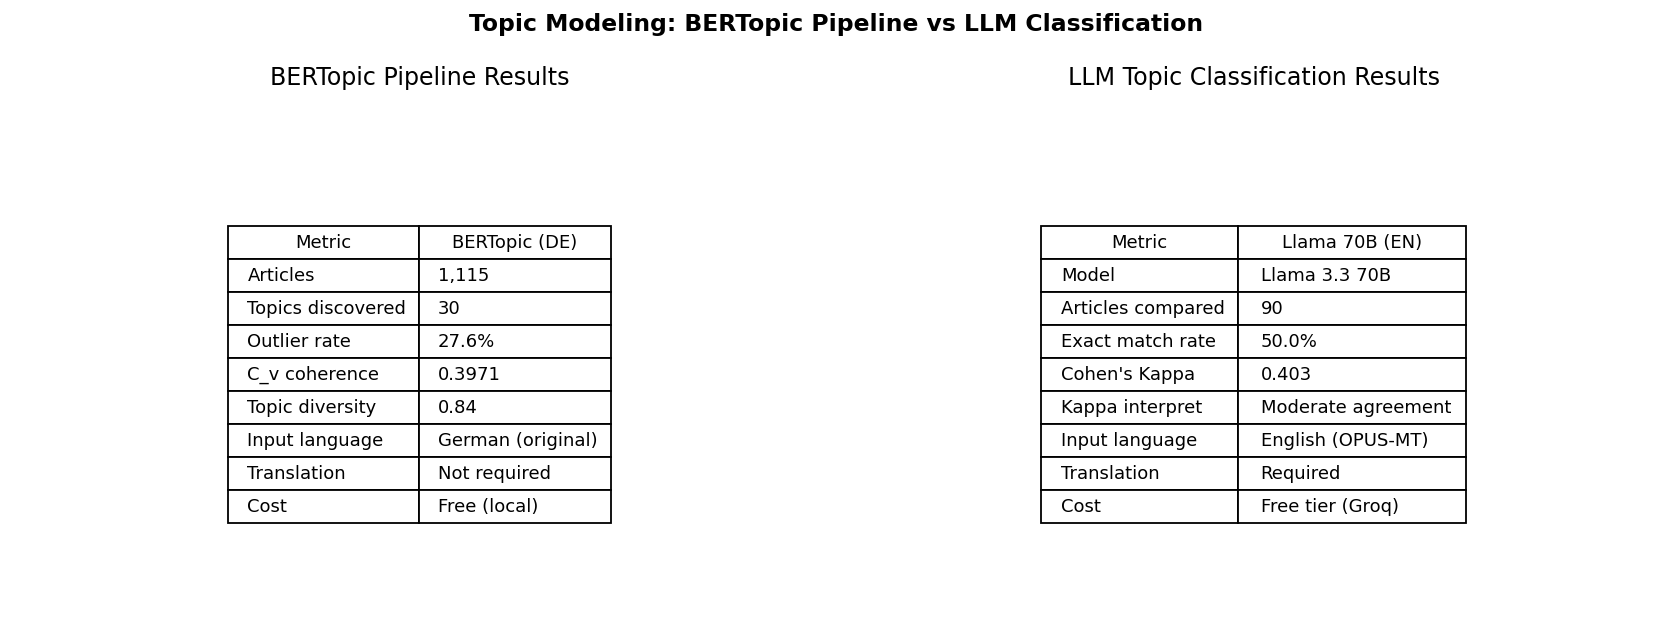

Figure 5 saved


In [10]:
# Figure 5: Topic modeling summary
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Topic Modeling: BERTopic Pipeline vs LLM Classification',
             fontsize=13, fontweight='bold')

# Left: BERTopic summary table
ax = axes[0]
ax.axis('off')
bertopic_table = [
    ['Articles',         f"{topic_summary['n_articles_full_corpus']:,}"],
    ['Topics discovered', str(topic_summary['n_topics_discovered'])],
    ['Outlier rate',     f"{topic_summary['outlier_rate']*100:.1f}%"],
    ['C_v coherence',    f"{topic_summary['cv_coherence']:.4f}"],
    ['Topic diversity',  f"{topic_summary['topic_diversity']:.2f}"],
    ['Input language',   'German (original)'],
    ['Translation',      'Not required'],
    ['Cost',             'Free (local)'],
]
table = ax.table(cellText=bertopic_table,
                 colLabels=['Metric', 'BERTopic (DE)'],
                 loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width([0, 1])
table.scale(1, 1.5)
ax.set_title('BERTopic Pipeline Results', pad=20)

# Right: LLM topic agreement
ax2 = axes[1]
ax2.axis('off')
llm_topic_table = [
    ['Model',            'Llama 3.3 70B'],
    ['Articles compared', str(llama_summary['n_articles_topic'])],
    ['Exact match rate', f"{llama_summary['topic_exact_match']:.1%}"],
    ["Cohen's Kappa",    f"{llama_summary['topic_cohens_kappa']:.3f}"],
    ['Kappa interpret',  'Moderate agreement'],
    ['Input language',   'English (OPUS-MT)'],
    ['Translation',      'Required'],
    ['Cost',             'Free tier (Groq)'],
]
table2 = ax2.table(cellText=llm_topic_table,
                   colLabels=['Metric', 'Llama 70B (EN)'],
                   loc='center', cellLoc='left')
table2.auto_set_font_size(False)
table2.set_fontsize(10)
table2.auto_set_column_width([0, 1])
table2.scale(1, 1.5)
ax2.set_title('LLM Topic Classification Results', pad=20)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'final_topic_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

In [11]:
# Master trade-off table
master_table = pd.DataFrame([
    {
        'System'             : 'spaCy de_core_news_lg',
        'Task'               : 'NER',
        'Approach'           : 'Pipeline',
        'Input'              : 'German',
        'NER F1'             : 0.394,
        'NER Precision'      : round(ner_prec['spaCy (DE)'], 3),
        'NER Recall'         : round(ner_rec['spaCy (DE)'], 3),
        'Topic metric'       : 'N/A',
        'Translation needed' : 'No',
        'Cost'               : 'Free',
        'Reproducibility'    : 'High',
        'Transparency'       : 'High',
        'API dependency'     : 'None',
    },
    {
        'System'             : 'Stanza German',
        'Task'               : 'NER',
        'Approach'           : 'Pipeline',
        'Input'              : 'German',
        'NER F1'             : 0.520,
        'NER Precision'      : round(ner_prec['Stanza (DE)'], 3),
        'NER Recall'         : round(ner_rec['Stanza (DE)'], 3),
        'Topic metric'       : 'N/A',
        'Translation needed' : 'No',
        'Cost'               : 'Free',
        'Reproducibility'    : 'High',
        'Transparency'       : 'High',
        'API dependency'     : 'None',
    },
    {
        'System'             : 'Flair German',
        'Task'               : 'NER',
        'Approach'           : 'Pipeline',
        'Input'              : 'German',
        'NER F1'             : 0.717,
        'NER Precision'      : round(ner_prec['Flair (DE)'], 3),
        'NER Recall'         : round(ner_rec['Flair (DE)'], 3),
        'Topic metric'       : 'N/A',
        'Translation needed' : 'No',
        'Cost'               : 'Free',
        'Reproducibility'    : 'High',
        'Transparency'       : 'Medium',
        'API dependency'     : 'None',
    },
    {
        'System'             : 'BERTopic multilingual',
        'Task'               : 'Topic Modeling',
        'Approach'           : 'Pipeline',
        'Input'              : 'German',
        'NER F1'             : 'N/A',
        'NER Precision'      : 'N/A',
        'NER Recall'         : 'N/A',
        'Topic metric'       : f"C_v={topic_summary['cv_coherence']:.4f}",
        'Translation needed' : 'No',
        'Cost'               : 'Free',
        'Reproducibility'    : 'High (seed=42)',
        'Transparency'       : 'High (keywords)',
        'API dependency'     : 'None',
    },
    {
        'System'             : 'Qwen2.5-7B-Instruct',
        'Task'               : 'NER',
        'Approach'           : 'LLM (7B)',
        'Input'              : 'English (OPUS-MT)',
        'NER F1'             : 0.191,
        'NER Precision'      : round(ner_prec['Qwen (EN)'], 3),
        'NER Recall'         : round(ner_rec['Qwen (EN)'], 3),
        'Topic metric'       : 'Not completed',
        'Translation needed' : 'Yes',
        'Cost'               : 'Free tier (exhausted)',
        'Reproducibility'    : 'Medium',
        'Transparency'       : 'Low',
        'API dependency'     : 'High (credit limits)',
    },
    {
        'System'             : 'Llama 3.3 70B',
        'Task'               : 'NER + Topic',
        'Approach'           : 'LLM (70B)',
        'Input'              : 'English (OPUS-MT)',
        'NER F1'             : llama_f1,
        'NER Precision'      : llama_summary['ner_macro_precision'],
        'NER Recall'         : llama_summary['ner_macro_recall'],
        'Topic metric'       : f"κ={llama_summary['topic_cohens_kappa']:.3f}, match={llama_summary['topic_exact_match']:.1%}",
        'Translation needed' : 'Yes',
        'Cost'               : 'Free tier (Groq)',
        'Reproducibility'    : 'Medium',
        'Transparency'       : 'Low',
        'API dependency'     : 'Medium (Groq)',
    },
])

print('── Master Trade-off Table ──')
print(master_table.set_index('System').to_string())
master_table.to_csv(DATA_PROC / 'final_comparison_table.csv', index=False)
print('\nSaved: final_comparison_table.csv')

── Master Trade-off Table ──
                                 Task   Approach              Input NER F1 NER Precision NER Recall          Topic metric Translation needed                   Cost Reproducibility     Transparency        API dependency
System                                                                                                                                                                                                                    
spaCy de_core_news_lg             NER   Pipeline             German  0.394         0.262      0.956                   N/A                 No                   Free            High             High                  None
Stanza German                     NER   Pipeline             German   0.52         0.383      0.956                   N/A                 No                   Free            High             High                  None
Flair German                      NER   Pipeline             German  0.717         0.593      0

In [12]:
# Key findings
print('=' * 65)
print('KEY FINDINGS')
print('=' * 65)
print(f"""
NER TASK
  Gold standard    : Full cross-model agreement (Fleiss κ=0.717)
  N articles       : 183 (Qwen/Llama) / 199 (pipeline)

  Pipeline systems (German, local, free):
    spaCy   F1 = {spacy_f1:.3f}  P={ner_prec['spaCy (DE)']:.3f}  R={ner_rec['spaCy (DE)']:.3f}
    Stanza  F1 = {stanza_f1:.3f}  P={ner_prec['Stanza (DE)']:.3f}  R={ner_rec['Stanza (DE)']:.3f}
    Flair   F1 = {flair_f1:.3f}  P={ner_prec['Flair (DE)']:.3f}  R={ner_rec['Flair (DE)']:.3f}

  LLM systems (English translations, API-dependent):
    Qwen 7B   F1 = {qwen_f1:.3f}  P={ner_prec['Qwen (EN)']:.3f}  R={ner_rec['Qwen (EN)']:.3f}
    Llama 70B F1 = {llama_f1:.3f}  P={llama_summary['ner_macro_precision']:.3f}  R={llama_summary['ner_macro_recall']:.3f}

  Scale effect (7B → 70B)     : +{llama_f1 - qwen_f1:.3f} F1
  Pipeline advantage (Flair vs Llama 70B): +{flair_f1 - llama_f1:.3f} F1
  All pipeline recall          : 0.956 (high coverage)
  Translation quality effect   : p=0.303 (not significant)

ENTITY TYPE ANALYSIS
  PER  : Flair best (0.922), Llama 70B better than Qwen
  LOC  : Flair best (0.822), consistent pipeline advantage
  ORG  : All systems struggle; pipeline still wins
  MISC : Hardest for all; near-zero for LLMs

TOPIC MODELING TASK
  BERTopic : {topic_summary['n_topics_discovered']} topics, C_v={topic_summary['cv_coherence']:.4f}, diversity={topic_summary['topic_diversity']:.2f}
  Llama 70B: κ={llama_summary['topic_cohens_kappa']:.3f} (moderate), match={llama_summary['topic_exact_match']:.1%}
  N articles compared: {llama_summary['n_articles_topic']} (93 excluded as BERTopic outliers)
  Qwen 7B  : Not completed (API credit exhaustion)
""")

print('=' * 65)
print('RESEARCH QUESTION ANSWER')
print('=' * 65)
print("""
Can task-specific NLP pipelines match LLM performance on cross-lingual
text analysis while offering advantages in transparency, reproducibility,
and resource efficiency?

ANSWER: Yes — and the advantage is robust across LLM scales.

On NER, pipeline systems substantially outperform both a 7B LLM
(Flair F1=0.717 vs Qwen F1=0.191, Δ=+0.526) and a 70B LLM
(Flair F1=0.717 vs Llama F1=0.340, Δ=+0.377). Model scale improves
LLM performance (+0.149 F1 from 7B to 70B), but does not close the
pipeline advantage. Llama 70B remains below even spaCy, the weakest
pipeline system (F1=0.394).

Pipeline systems operate on the original German text, require no
translation, are fully reproducible, and have no API dependencies.

On topic modeling, BERTopic discovers interpretable topics directly
from German text (C_v=0.397). Llama 70B shows moderate agreement
with BERTopic assignments (κ=0.403, match=50%), suggesting LLMs can
partially recover topic structure but with significant inconsistency.
""")

KEY FINDINGS

NER TASK
  Gold standard    : Full cross-model agreement (Fleiss κ=0.717)
  N articles       : 183 (Qwen/Llama) / 199 (pipeline)

  Pipeline systems (German, local, free):
    spaCy   F1 = 0.394  P=0.262  R=0.956
    Stanza  F1 = 0.520  P=0.383  R=0.956
    Flair   F1 = 0.717  P=0.593  R=0.956

  LLM systems (English translations, API-dependent):
    Qwen 7B   F1 = 0.191  P=0.160  R=0.306
    Llama 70B F1 = 0.340  P=0.260  R=0.570

  Scale effect (7B → 70B)     : +0.149 F1
  Pipeline advantage (Flair vs Llama 70B): +0.377 F1
  All pipeline recall          : 0.956 (high coverage)
  Translation quality effect   : p=0.303 (not significant)

ENTITY TYPE ANALYSIS
  PER  : Flair best (0.922), Llama 70B better than Qwen
  LOC  : Flair best (0.822), consistent pipeline advantage
  ORG  : All systems struggle; pipeline still wins
  MISC : Hardest for all; near-zero for LLMs

TOPIC MODELING TASK
  BERTopic : 30 topics, C_v=0.3971, diversity=0.84
  Llama 70B: κ=0.403 (moderate), mat

In [13]:
# Limitations
print('=' * 65)
print('LIMITATIONS')
print('=' * 65)
print("""
1. GOLD STANDARD
   NER uses cross-model agreement as silver standard (not human gold).
   Conservative but reproducible. May underestimate LLM performance
   on genuinely ambiguous entities.

2. INCOMPLETE LLM COVERAGE
   Qwen 7B: 16/199 articles failed (API credit exhaustion).
   Qwen topic classification: not completed (same reason).
   Llama 70B topic comparison: 90/183 articles (93 BERTopic outliers).

3. TRANSLATION QUALITY
   91/199 articles below BERTScore 0.75 threshold. Translation
   quality was not found to significantly affect LLM NER F1 (p=0.303),
   suggesting bottleneck is LLM extraction behaviour, not input quality.

4. TOPIC COHERENCE
   BERTopic C_v=0.397 is below the >0.5 good threshold, reflecting
   domain specificity of sustainable building vocabulary.

5. LLM SCOPE
   Two LLMs tested (7B and 70B). GPT-4 or Claude-class models may
   perform differently but require paid API access.
""")

print('=' * 65)
print('FUTURE WORK')
print('=' * 65)
print("""
1. Human annotation of 50-100 articles as true gold standard
2. Test GPT-4 / Claude on same tasks with paid API access
3. German-specific BERTopic embeddings (deepset/gbert-base)
4. Frame detection as additional comparison task
5. Temporal trend analysis of topic evolution 2015-2025
6. Qwen 7B topic classification if credits are renewed
""")

LIMITATIONS

1. GOLD STANDARD
   NER uses cross-model agreement as silver standard (not human gold).
   Conservative but reproducible. May underestimate LLM performance
   on genuinely ambiguous entities.

2. INCOMPLETE LLM COVERAGE
   Qwen 7B: 16/199 articles failed (API credit exhaustion).
   Qwen topic classification: not completed (same reason).
   Llama 70B topic comparison: 90/183 articles (93 BERTopic outliers).

3. TRANSLATION QUALITY
   91/199 articles below BERTScore 0.75 threshold. Translation
   quality was not found to significantly affect LLM NER F1 (p=0.303),
   suggesting bottleneck is LLM extraction behaviour, not input quality.

4. TOPIC COHERENCE
   BERTopic C_v=0.397 is below the >0.5 good threshold, reflecting
   domain specificity of sustainable building vocabulary.

5. LLM SCOPE
   Two LLMs tested (7B and 70B). GPT-4 or Claude-class models may
   perform differently but require paid API access.

FUTURE WORK

1. Human annotation of 50-100 articles as true gold sta

In [14]:
# Save final summary
final_summary = {
    'thesis_title' : 'Task-Specific NLP Pipelines vs LLMs for Cross-Lingual Text Analysis',
    'corpus': {
        'total_articles'  : 1115,
        'validation_sample': 199,
        'llm_overlap'     : 183,
        'sources'         : 4,
        'date_range'      : '2015-2025',
        'language'        : 'German',
    },
    'ner_results': {
        'gold_standard'   : 'Full cross-model agreement (Fleiss kappa=0.717)',
        'n_gold_entities' : ner_summary['n_gold_entities'],
        'macro_f1': {
            'spacy'    : spacy_f1,
            'stanza'   : stanza_f1,
            'flair'    : flair_f1,
            'qwen_7b'  : qwen_f1,
            'llama_70b': llama_f1,
        },
        'scale_effect_7b_to_70b'         : round(llama_f1 - qwen_f1, 4),
        'pipeline_advantage_over_llama70b': round(flair_f1 - llama_f1, 4),
        'translation_quality_effect_p'   : 0.3034,
    },
    'topic_results': {
        'bertopic_topics'    : topic_summary['n_topics_discovered'],
        'bertopic_cv'        : topic_summary['cv_coherence'],
        'bertopic_diversity' : topic_summary['topic_diversity'],
        'llama_70b_kappa'    : llama_summary['topic_cohens_kappa'],
        'llama_70b_match'    : llama_summary['topic_exact_match'],
        'qwen_7b'            : 'not_completed',
    },
    'key_finding': (
        'Pipeline systems outperform LLMs on NER at both 7B and 70B scale '
        '(Flair F1=0.717 vs Llama 70B F1=0.340 vs Qwen 7B F1=0.191), '
        'operating on German directly with no translation overhead, '
        'full reproducibility, and no API dependencies.'
    ),
}

with open(DATA_PROC / 'thesis_final_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print('Saved: thesis_final_summary.json')
print('\nAll notebooks complete. Ready for thesis writing phase.')
print(f'Figures saved to: {FIGURES_DIR}')

Saved: thesis_final_summary.json

All notebooks complete. Ready for thesis writing phase.
Figures saved to: /content/drive/MyDrive/thesis/Project/Outputs/Figures


## Pipeline sequence, complete

```
01_corpus_audit → 1,115 articles, 4 sources, 2015–2025
02_preprocessing → OPUS-MT translation, BERTScore quality
03_ner_pipeline → spaCy / Stanza / Flair on German, Fleiss κ=0.717
04_ner_llm → Qwen 7B on English, 183/199 completed
05_ner_comparison → F1 comparison, Flair wins (0.717 vs 0.191)
06_topic_modeling → BERTopic 30 topics, C_v=0.397, Qwen LLM not completed
07_final_comparison → Cross-task synthesis (this notebook, updated)
08_extended_analysis → Temporal, source, compound analysis
09_llama70b_comparison → Llama 70B NER (F1=0.340) + topic (κ=0.403)
```

### Final NER leaderboard

| Rank | System | F1 | Type |
|------|--------|----|------|
| 1 | Flair (DE) | 0.717 | Pipeline |
| 2 | Stanza (DE) | 0.520 | Pipeline |
| 3 | spaCy (DE) | 0.394 | Pipeline |
| 4 | Llama 3.3 70B (EN) | 0.340 | LLM 70B |
| 5 | Qwen 2.5 7B (EN) | 0.191 | LLM 7B |
